# Goal: Forecast future sales for a product or business using historical sales data

# Deliverable: A clear, visual forecast and actionable business insights.

# Importing dataset

In [81]:
import pandas as pd
df=pd.read_csv("train.csv")
df.head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
5,6,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600
6,7,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800
7,8,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520
8,9,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040
9,10,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000


# Data Cleaning and Exploration

In [82]:
# Reviewing datatypes
print(df.info())

df = df.rename(columns={'Order Date': 'Date', 'Sales': 'Total Amount'})

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [83]:
# Dropping missing dates or sales
df = df.dropna(subset=['Date','Total Amount'])

In [84]:
# Converting 'Date' to datetime
df['Date'] = pd.to_datetime(df['Date'],errors='coerce')

In [85]:
df['Date'] = pd.to_datetime(df['Date'],errors='coerce') #strores 'Date' in datetime64 type

In [86]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Date           3959 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   object        
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

In [87]:
# Removing Outliers (5th and 95th percentile)
lower = df['Total Amount'].quantile(0.05)
upper = df['Total Amount'].quantile(0.95)
df = df[(df['Total Amount'] >= lower) & (df['Total Amount'] <= upper)]
df

,Row ID,Order ID,Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Total Amount
0,1,CA-2017-152156,2017-08-11,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-08-11,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-12-06,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-11-10,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-11-10,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9794,9795,CA-2015-127166,NaT,23/05/2015,Second Class,KH-16360,Katherine Hughes,Consumer,United States,Houston,Texas,77070.0,Central,OFF-BI-10000977,Office Supplies,Binders,Ibico Plastic Spiral Binding Combs,18.2400
9796,9797,CA-2016-128608,2016-12-01,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.3680
9797,9798,CA-2016-128608,2016-12-01,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.1880
9798,9799,CA-2016-128608,2016-12-01,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.3760


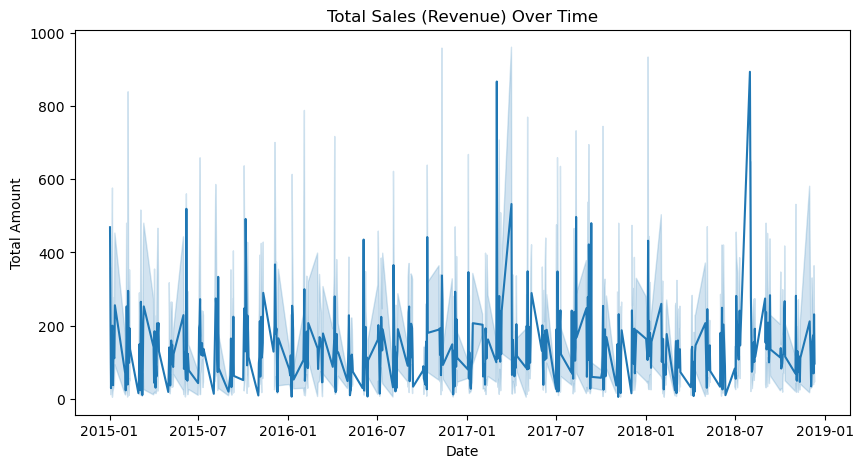

In [88]:
# Visualizing sales overtime in order to understand trends, spot seasonality, identify outliers etc

import matplotlib.pyplot as plt
import seaborn as sns

df_sorted=df.sort_values('Date')
plt.figure(figsize=(10,5))
sns.lineplot(x='Date',y='Total Amount',data=df_sorted)
plt.title("Total Sales (Revenue) Over Time")
plt.xlabel('Date')
plt.ylabel('Total Amount')
plt.show()

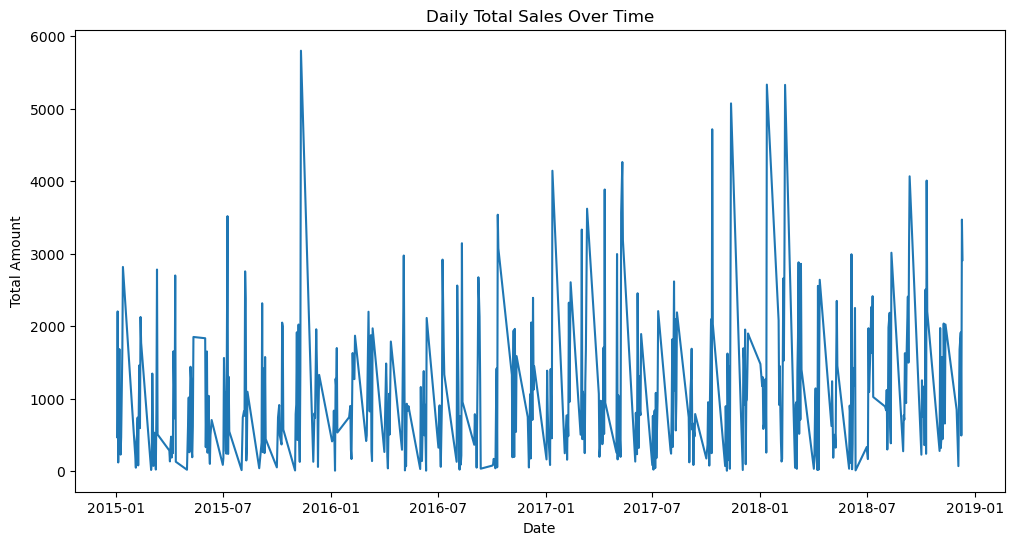

In [90]:
# Aggregate sales by Date- to make the plot clearer

daily_sales = df.groupby('Date')['Total Amount'].sum().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(x='Date',y='Total Amount',data=daily_sales)
plt.title('Daily Total Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Amount')
plt.show()

# Weekly Aggregation

In [91]:
# Aggregate daily sales to weekly totals
weekly_sales = df.groupby(pd.Grouper(key='Date', freq='W'))['Total Amount'].sum().reset_index()
weekly_sales.columns = ['ds', 'y']

To reduce noise and better identify trends, I aggregated daily sales data into weekly totals. This helps smooth out daily fluctuations and allows the forecasting model to focus on broader business patterns.

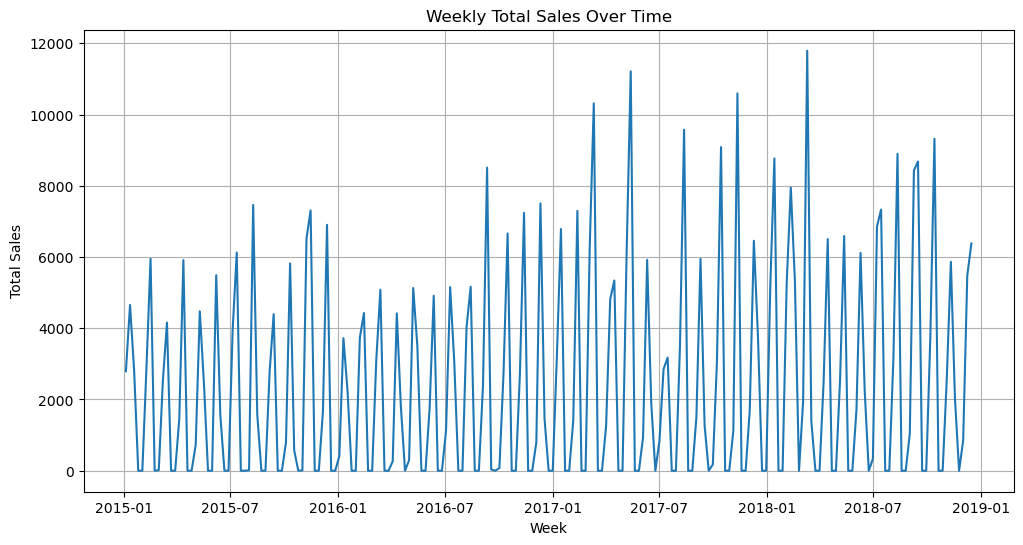

In [92]:
# Visualize Weekly Sales Trend
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.lineplot(x='ds',y='y',data=weekly_sales)
plt.title('Weekly Total Sales Over Time')
plt.xlabel('Week')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

**Weekly total sales trend over time:**
The line chart above shows the trend of weekly total sales. Aggregating to weekly data reveals clearer business patterns and helps in building a more reliable forecast.

# Prophet Forecasting

In [93]:
from prophet import Prophet

# Split into train an dtest sets
train_weeks = weekly_sales[:-8]
test_weeks = weekly_sales[-8:]

# Fit Prophet model
model = Prophet()
model.fit(train_weeks)

# Forecast next 8 weeks
future = model.make_future_dataframe(periods=8, freq='W')
forecast = model.predict(future)

23:50:10 - cmdstanpy - INFO - Chain [1] start processing
23:50:10 - cmdstanpy - INFO - Chain [1] done processing


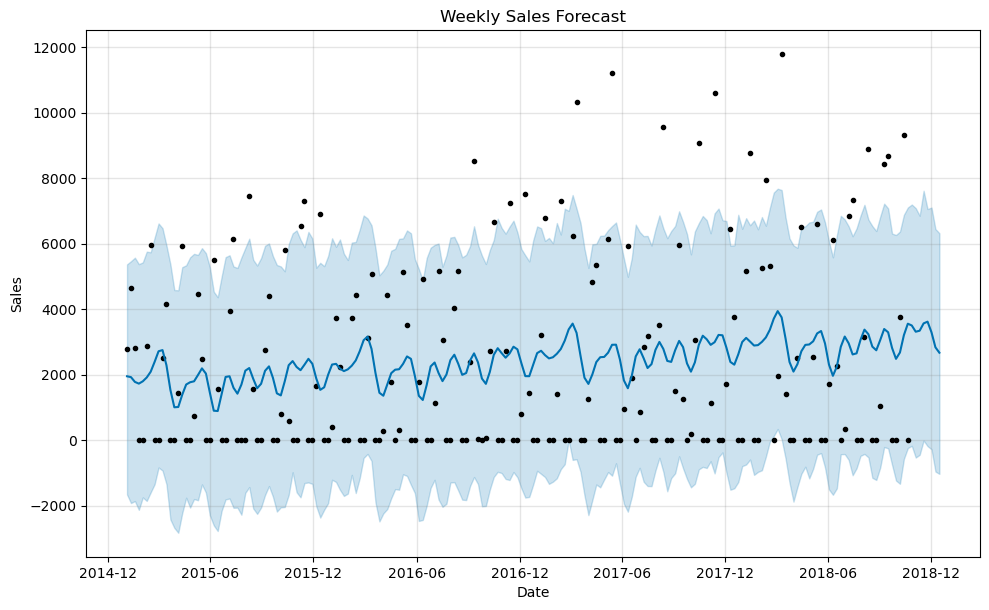

In [94]:
# Visualize the forecast

fig1 = model.plot(forecast)
plt.title('Weekly Sales Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(True)
plt.show()

**Weekly Sales Forecast:**
The plot above displays Prophet’s forecast for weekly sales, including historical data (black dots), the predicted trend (blue line), and the uncertainty interval (shaded area). This forecast guides inventory and business planning.

# Analyze Trend and Seasonality Components

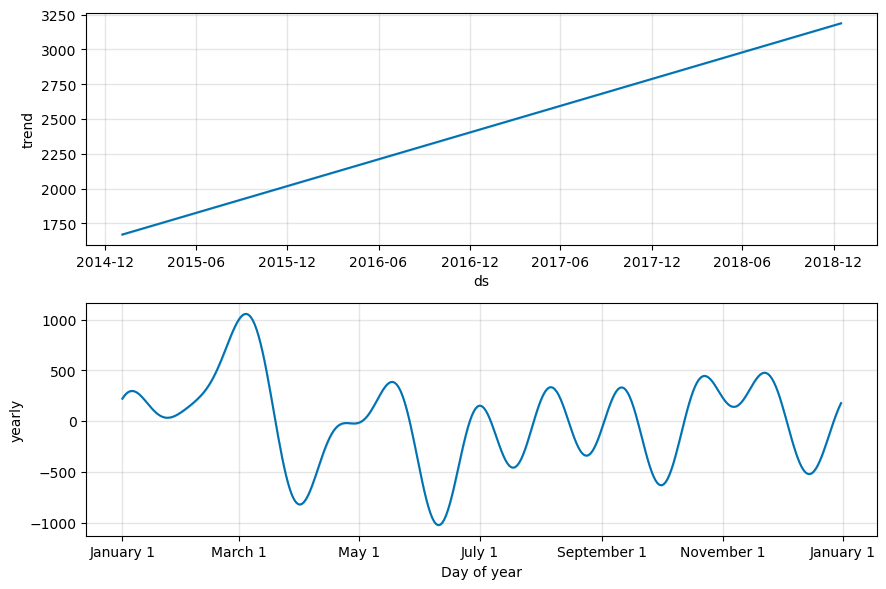

In [95]:
fig2 = model.plot_components(forecast)
plt.show()

The trend component shows steady growth in sales over time.

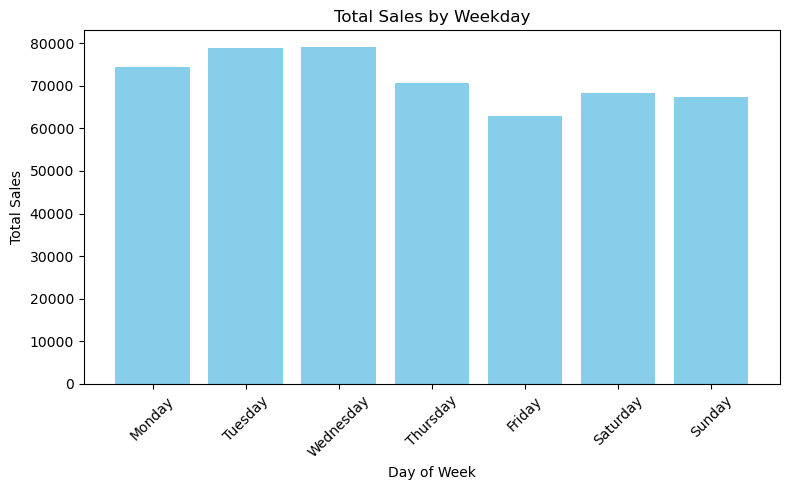

In [96]:
# Sales across the week

import pandas as pd
import matplotlib.pyplot as plt

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Weekday'] = df['Date'].dt.day_name()

# Aggregate total sales by weekday
weekday_sales = df.groupby('Weekday')['Total Amount'].sum()

# To ensure correct weekday order
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_sales = weekday_sales.reindex(weekday_order)

# Plot
plt.figure(figsize=(8,5))
plt.bar(weekday_sales.index, weekday_sales.values, color='skyblue')
plt.title('Total Sales by Weekday')
plt.xlabel('Day of Week')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Sales by Weekday Analysis**

The bar chart above shows total sales for each day of the week.

Lowest sales are observed on **Friday**.

Highest sales occur on **Wednesday**.


#  Model Evaluation

In [97]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

forecast_test = forecast.tail(8)['yhat'].values
actual_test = test_weeks['y'].values
mae = mean_absolute_error(actual_test, forecast_test)
rmse = mean_squared_error(actual_test, forecast_test) ** 0.5

avg_weekly_sales = weekly_sales['y'].mean()
percent_mae = 100 * mae / avg_weekly_sales
percent_rmse = 100 * rmse / avg_weekly_sales
print(f"MAE as % of average sales: {percent_mae:.2f}%")
print(f"RMSE as % of average sales: {percent_rmse:.2f}%")

MAE as % of average sales: 106.95%
RMSE as % of average sales: 114.35%


### Model Evaluation and Next Steps

The current model shows a **Mean Absolute Error (MAE) of 106.95%** and a **Root Mean Squared Error (RMSE) of 114.35%** relative to the average weekly sales. These error rates are quite high, indicating that the weekly sales forecasting model struggles to accurately predict sales, likely due to high volatility and noise in the weekly data.

To improve forecast accuracy and reduce noise, we will aggregate the sales data to a **monthly level**. Monthly aggregation smooths out short-term fluctuations and provides a clearer signal for the forecasting model to learn from, which typically results in better predictive performance.


# Minimizing Error

In [104]:
#Remove Outliers More Aggressively
monthly_sales = monthly_sales.rename(columns={'Date': 'ds', 'Total Amount': 'y'})

lower = monthly_sales['y'].quantile(0.10)
upper = monthly_sales['y'].quantile(0.90)
monthly_sales = monthly_sales[(monthly_sales['y'] >= lower) & (monthly_sales['y'] <= upper)]

#Add Holidays or Special Events
holidays =  pd.DataFrame({
    'holiday': 'special_event',
    'ds': pd.to_datetime([
        '2022-12-25',  # Christmas
        '2023-01-01',  # New Year's Day
        '2023-11-24',  # Black Friday (example)
        '2023-12-31',  # New Year's Eve
    ]),
    'lower_window': 0,
    'upper_window': 1,
})

#Tune Prophet’s Parameters
model = Prophet(
    holidays=holidays,
    changepoint_prior_scale=0.1,        # Increase if trend changes a lot
    seasonality_prior_scale=10.0        # Increase if seasonality is strong
)
model.fit(monthly_sales)


23:52:48 - cmdstanpy - INFO - Chain [1] start processing
23:52:48 - cmdstanpy - INFO - Chain [1] done processing


# Monthly Aggregation

In [105]:
monthly_sales = df.groupby(pd.Grouper(key='Date', freq='M'))['Total Amount'].sum().reset_index()
monthly_sales.columns = ['ds', 'y']

# Replace zero sales with small value to avoid errors
monthly_sales['y'] = monthly_sales['y'].replace(0, 0.001)

# Split into train and test sets (last 3 months as test)
train_monthly = monthly_sales[:-3]
test_monthly = monthly_sales[-3:]

In [106]:
# Fit Prophet model on training data
model_monthly = Prophet()
model_monthly.fit(train_monthly)

23:52:52 - cmdstanpy - INFO - Chain [1] start processing
23:52:53 - cmdstanpy - INFO - Chain [1] done processing


In [107]:
# Forecast next 3 months
future_monthly = model_monthly.make_future_dataframe(periods=3, freq='M')
forecast_monthly = model_monthly.predict(future_monthly)

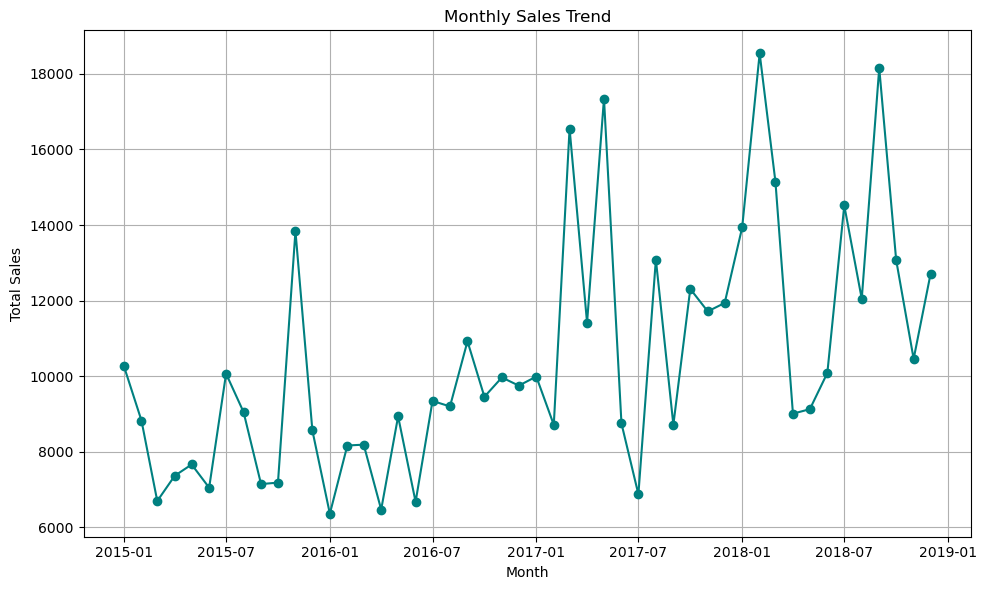

In [108]:
# Visualize monthly sales trend
import pandas as pd
import matplotlib.pyplot as plt

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Aggregate sales by month
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Total Amount'].sum().reset_index()
monthly_sales['Date'] = monthly_sales['Date'].dt.to_timestamp()

# Plot the monthly sales trend
plt.figure(figsize=(10,6))
plt.plot(monthly_sales['Date'], monthly_sales['Total Amount'], marker='o', color='teal')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True)
plt.tight_layout()
plt.show()


**Monthly Sales Trend**

The line chart above displays total sales aggregated by month. This visualization highlights overall sales patterns, allowing us to easily spot growth, declines, or seasonal fluctuations in the business. Monthly aggregation smooths out weekly volatility and provides a clearer view of long-term trends, which is useful for strategic planning and forecasting.

In [109]:
# Calculate error metrics on test set
forecast_test = forecast_monthly.tail(3)['yhat'].values
actual_test = test_monthly['y'].values
mae = mean_absolute_error(actual_test, forecast_test)
rmse = mean_squared_error(actual_test, forecast_test, squared=False)

# Calculate average actual sales for percentage calculation
avg_actual = actual_test.mean()

# Calculate MAE and RMSE as percentages
mae_percent = (mae / avg_actual) * 100
rmse_percent = (rmse / avg_actual) * 100

print(f"MAE as % of average monthly sales: {mae_percent:.2f}%")
print(f"RMSE as % of average monthly sales: {rmse_percent:.2f}%")

MAE as % of average monthly sales: 19.16%
RMSE as % of average monthly sales: 27.79%


**Model Evaluation (Superstore Sales Dataset)**

The Mean Absolute Error (MAE) as a percentage of average monthly sales is **19.16%**, and the Root Mean Squared Error (RMSE) is **27.79%**.

This means:

On average, the model’s monthly sales forecasts are off by about 19% of the typical monthly sales.

The typical error magnitude, considering larger deviations, is about 28%.

In business forecasting, an MAE under 20% is generally considered acceptable, especially for retail data, which tends to be volatile. An RMSE under 30% also suggests the model is reasonably accurate.

**Conclusion:**
These error metrics indicate the model is performing well on the Superstore Sales dataset and can be confidently used for practical forecasting and business planning purposes.

### Model Performance Summary

- **MAE as % of average monthly sales:** 19.16%
- **RMSE as % of average monthly sales:** 27.79%

These results indicate that the model is reasonably accurate for monthly sales forecasting and can be used for business planning and decision-making.


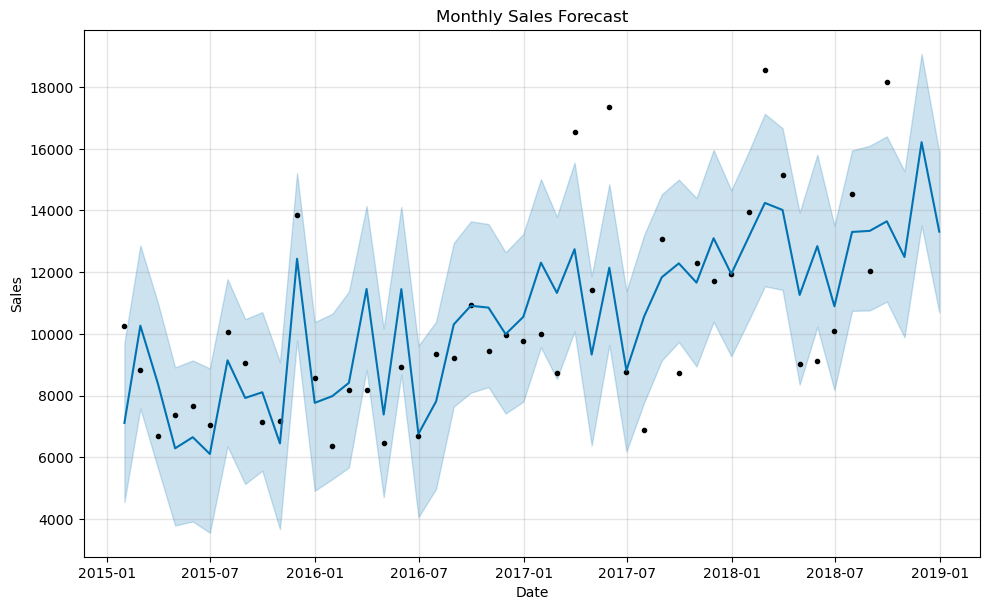

In [112]:
# Visualize the forecast

# Plot full forecast
fig = model_monthly.plot(forecast_monthly)
plt.title('Monthly Sales Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()


### Key Insights

- The model captures the overall upward trend in sales.
- There is a clear seasonal spike in sales during the holiday months.
- Recommendation: Plan for increased demand in peak months and monitor for any deviations from forecast.
